In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.optimize import curve_fit

In [2]:
paths = ['2022Apr', '2024Nov', '2025Oct', '2026Aug']

In [118]:
tsv_name = 'disc_calibration.tsv'
rel = []
for path in paths:
    tsv = pd.read_csv(f'{path}/{tsv_name}', sep = '\t')
    tsv['ID'] = tsv['# portID'] * 3072 + tsv['slaveID'] * 1024 + tsv['chipID'] * 64 + tsv['channelID']
    rel.append(tsv)
print(rel[2][0:3])

   # portID  slaveID  chipID  channelID  baseline_T  baseline_E    zero_T1  \
0         0        0       0          0          45           3  48.141235   
1         0        0       0          1          52           7  55.033065   
2         0        0       0          2          49           7  59.290371   

     zero_T2     zero_E  noise_T1  noise_T2   noise_E  ID  
0  60.676960  55.040924  0.753522  0.245613  0.530345   0  
1  60.308843  60.547364  1.060923  0.225876  0.327626   1  
2  60.397153  56.500000  0.590200  2.000000  0.050000   2  


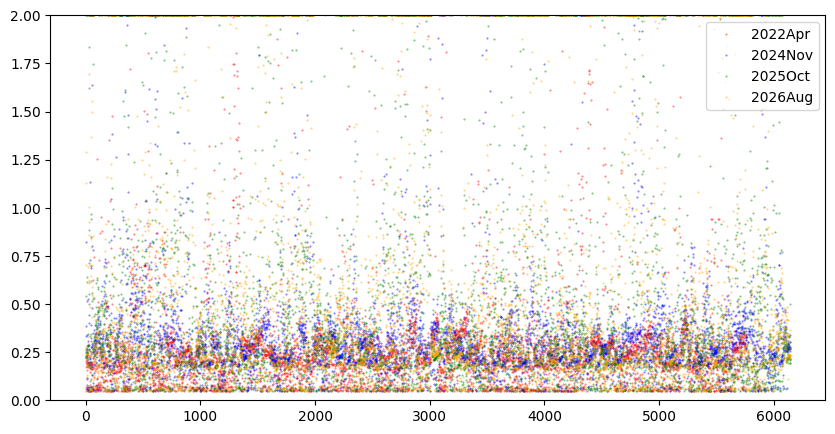

In [9]:
colname = 'noise_T2'
plt.figure(figsize = (10, 5))
plt.plot(range(len(rel[0])), rel[0][colname], 'o', label = '2022Apr', markersize = 0.5, color = 'red', alpha = 0.5)
plt.plot(range(len(rel[1])), rel[1][colname], 'o', label = '2024Nov', markersize = 0.5, color = 'blue', alpha = 0.5)
plt.plot(range(len(rel[2])), rel[2][colname], 'o', label = '2025Oct', markersize = 0.5, color = 'green', alpha = 0.5)
plt.plot(range(len(rel[3])), rel[3][colname], 'o', label = '2026Aug', markersize = 0.5, color = 'orange', alpha = 0.5)
plt.legend()
plt.ylim(0, 2)
plt.show()

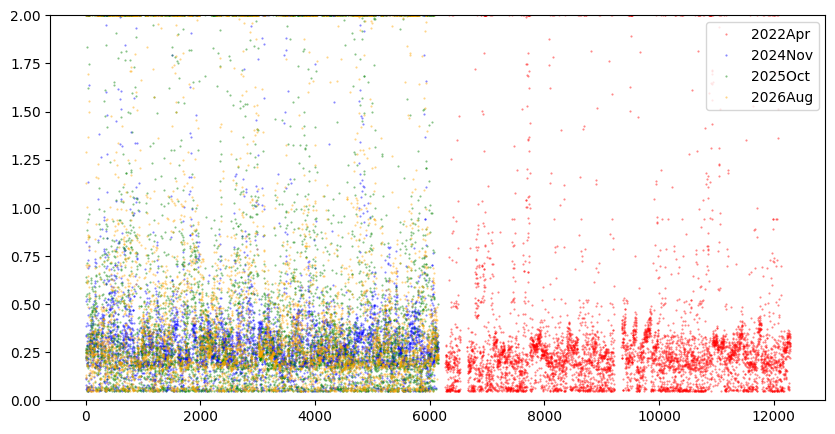

In [116]:
colname = 'noise_T2'
plt.figure(figsize = (10, 5))
plt.plot(rel[0]['ID'], rel[0][colname], 'o', label = '2022Apr', markersize = 0.5, color = 'red', alpha = 0.5)
plt.plot(rel[1]['ID'], rel[1][colname], 'o', label = '2024Nov', markersize = 0.5, color = 'blue', alpha = 0.5)
plt.plot(rel[2]['ID'], rel[2][colname], 'o', label = '2025Oct', markersize = 0.5, color = 'green', alpha = 0.5)
plt.plot(rel[3]['ID'], rel[3][colname], 'o', label = '2026Aug', markersize = 0.5, color = 'orange', alpha = 0.5)
plt.legend()
plt.ylim(0, 2)
plt.show()

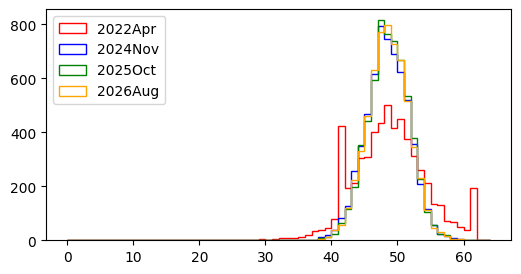

In [117]:
colname = 'baseline_T'
#bins=np.linspace(0, 2, 101)
bins = np.linspace(0,64, 65)
plt.figure(figsize = (6, 3))
plt.hist(rel[0][colname], bins = bins, histtype = 'step', label = '2022Apr', color = 'red')
plt.hist(rel[1][colname], bins = bins, histtype = 'step', label = '2024Nov', color = 'blue')
plt.hist(rel[2][colname], bins = bins, histtype = 'step', label = '2025Oct', color = 'green')
plt.hist(rel[3][colname], bins = bins, histtype = 'step', label = '2026Aug', color = 'orange')
plt.legend()
plt.show()